# 03 · The 12-Month Simulation

**Purpose:** Notebooks 03 and 04 answer what happens on a trip. This one answers the question leadership actually asked: over the next twelve months, at each price, how much revenue does the business make, and how wrong could that be?

1. A single expected-value calculation can't answer the second half
  - Point estimates invite a decision to be made as if the number were certain
  - Nobody could previously say how much risk a price change carried

**Four sources of uncertainty, deliberately separated**

| Source | Correlated across accounts? | Why it matters |
|---|---|---|
| Macroeconomic path | Yes | Moves how much travel happens at all |
| Market share | Yes | Moves whose travel is ours to price |
| Behavioral response | No | Each account draws its own state |
| Departure rate | Yes | Rare, expensive, and poorly estimated |

2. The correlation is the entire point
  - Drawing each account independently would let good and bad outcomes cancel across 50,000 accounts, collapsing the distribution to a spike — a precision the analysis hasn't earned
  - Macro and share draws are made once per iteration and applied to everyone, producing an honest spread
3. Two known biases, both pushing the same way
  - Notebook 01 §6.2 found the price response under-stated out of region
  - Notebook 02 §5 found reduction depth under-stated by label contamination
  - Both make a price rise look safer than it is; every scenario is run twice — as fitted, and with both corrections applied — and the recommendation is read off the conservative case


In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found — run data/00_generate_and_validate_data.ipynb and notebooks 01–02 first.")


accounts = load("accounts")
macro = load("macro")
trips = load("trips").merge(accounts, on="account_id", how="left")
scored = load("scored_trips")
rev_tbl = load("revenue_by_state")
model_meta = load("model_meta").set_index("key")["value"]
mag_meta = load("magnitude_meta").set_index("key")["value"]

CLASSES = ["no_purchase", "reduces", "unchanged", "increases"]
GRID = np.round(np.sort(rev_tbl["price_multiplier"].unique()), 4)

RESPONSE_RATIO = float(model_meta.get("response_ratio", 1.0))
DEPTH_BIAS = float(mag_meta.get("depth_bias", 1.0))
DEP_LO = float(model_meta.get("departure_lo", 0.002))
DEP_HI = float(model_meta.get("departure_hi", 0.006))

SURFACE = "#ffffff"
INK = "#0b0b0b"
MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
ACCENT = "#2a78d6"
ACCENT2 = "#eb6834"
RED = "#e34948"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "font.size": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

print(f"price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps")
print(f"response ratio (03 §6.2): {RESPONSE_RATIO:.2f}x")
print(f"depth bias     (04 §5)  : {DEPTH_BIAS:.2f}x")
print(f"departure rate 95% CI   : {DEP_LO:.4%} to {DEP_HI:.4%}")

price grid: 0.900 to 1.200 in 13 steps
response ratio (03 §6.2): 1.49x
depth bias     (04 §5)  : 1.06x
departure rate 95% CI   : 0.6801% to 0.8843%


---
## 1 · What a Departure Actually Costs

**Purpose:** Prices what a departure actually costs, since the revenue table books `no_purchase` at zero — right for the pass, wrong for the relationship.

**Design Notes:**

1. Substituting an eSIM costs one trip's pass revenue; leaving costs the account's entire ARPU across every product for as long as they would have stayed
  - That loss lands outside the roaming P&L, exactly why a roaming-only analysis tends to miss it
2. Figures are illustrative, not drawn from any real book
  - Set explicitly so the assumption is visible and can be argued with, rather than buried in a constant
3. Departure is rare, so it barely moves the median — but expensive, so it dominates the left tail, which is what a pricing decision is actually risking

**Observations:**

1. Mean value of a lost account: $4,118 (consumer $3,293, business $7,000)
2. One lost account is worth about 65 pass purchases — a price rise adding a few dollars per trip can be net negative without ever looking like it


In [2]:
# Price Departure Cost
ARPU_CONSUMER, ARPU_BUSINESS = 65.0, 95.0     # $/line/month
RETAINED_MONTHS = 24                            # horizon over which a lost account is counted

acct = accounts[["account_id", "is_business", "lines_on_account"]].copy()
acct["monthly_arpu"] = acct["lines_on_account"] * np.where(
    acct["is_business"], ARPU_BUSINESS, ARPU_CONSUMER)
acct["departure_cost"] = acct["monthly_arpu"] * RETAINED_MONTHS

print(f"Mean value of a lost account: ${acct.departure_cost.mean():,.0f}")
print(f"  consumer ${acct.loc[~acct.is_business, 'departure_cost'].mean():,.0f}   "
      f"business ${acct.loc[acct.is_business, 'departure_cost'].mean():,.0f}")

travellers = trips["account_id"].unique()
mean_trip_rev = trips.loc[trips.pass_revenue > 0, "pass_revenue"].mean()
print(f"For scale: one lost account is worth about "
      f"{acct.departure_cost.mean() / mean_trip_rev:.0f} pass purchases.")
print("A price rise that adds a few dollars per trip and costs a handful of")
print("relationships can be net negative without ever looking like it.")

Mean value of a lost account: $4,118
  consumer $3,293   business $7,000
For scale: one lost account is worth about 65 pass purchases.
A price rise that adds a few dollars per trip and costs a handful of
relationships can be net negative without ever looking like it.


---
## 2 · Building the Forward Year

**Purpose:** Builds a forward 12-month trip panel, since the simulation projects next year, not the historical one.

**Design Notes:**

1. Each account's trip pattern is carried forward and re-seasonalised; the macro path is regenerated per iteration
2. Trip volume scales, trips don't get invented
  - Each historical trip carries forward with a probability set by the macro and share draws, rather than generating new synthetic trips
  - Keeps the account mix stable and confines the uncertainty to volume, where the evidence actually is
3. Seasonality is reapplied, not inherited
  - The historical window covers two years with its own macro path; reusing it would bake one realisation of the economy into every iteration

**Observations:**

1. Forward panel: 52,500 trips across 22,328 accounts
2. Months 0-11, seasonality range 0.87 to 1.15


In [3]:
# Build Forward Panel
last12 = trips[trips["month"] >= trips["month"].max() - 11].copy()
last12["fwd_month"] = last12["month"] - last12["month"].min()

# Strip the historical macro effect so it can be redrawn per iteration
hist_mult = macro.set_index("month")["travel_multiplier"]
last12["hist_macro_mult"] = last12["month"].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

rev_wide = rev_tbl.pivot_table(index="trip_id", columns="price_multiplier",
                               values=[f"rev_{c}" for c in CLASSES])
prob_wide = scored.set_index("trip_id")[[f"p_{c}" for c in CLASSES]]

panel = last12[["trip_id", "account_id", "fwd_month", "is_business",
                "lines_traveling", "days_traveled"]].copy()
panel = panel[panel["trip_id"].isin(prob_wide.index) & panel["trip_id"].isin(rev_wide.index)]
panel = panel.merge(acct[["account_id", "departure_cost"]], on="account_id", how="left")
panel["season"] = fwd_season[panel["fwd_month"].to_numpy()]
panel["hist_macro_mult"] = last12.set_index("trip_id").loc[panel.trip_id, "hist_macro_mult"].to_numpy()

print(f"forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts")
print(f"months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}")

forward panel: 52,500 trips across 22,328 accounts
months 0-11, seasonality range 0.87 to 1.15


---
## 3 · The Simulation

**Purpose:** Simulates one 12-month iteration's revenue, combining macro, share, behavioral, and departure draws with the right correlation structure.

**Design Notes:**

1. One iteration
  - Draw an AR(1) macro path for twelve months — one path, shared by every account
  - Draw a market share drift — also shared
  - Draw a departure rate from the bootstrapped interval in notebook 01 §10
  - For each trip, decide whether it happens (macro × share × seasonality), then draw its state from the model's probabilities at the chosen price
  - Sum pass revenue, subtract the value of accounts lost
2. Steps 1-3 are drawn once per iteration; step 4 is drawn per trip — the difference between an honest distribution and a spike
3. Antithetic pairing halves the variance for free: each macro path runs alongside its mirror image, so a strong economy and a weak one appear in equal measure rather than by luck of the draw
4. Probabilities shifted in log-probability space, not logit space
  - An earlier version's softmax(logit(p)) renormalised odds rather than probabilities, understating a 0.099 walk-away risk as 0.036
5. Forward macro path drawn from the same phi=0.85/gamma=0.55 process as the data notebook's make_macro(), not a separately-guessed pair

**Observations:**

1. Join guard passes: P(no_purchase) matches exactly between scored_trips (0.0932) and the simulation's own probability function at price 1.0
2. Sanity check across three prices confirms probability shifts move smoothly with price (0.0793 -> 0.0932 -> 0.1205)
3. Baseline (no price change), 400 iterations: median net revenue $2,478,426
4. p5-p95: $1,830,557 to $2,834,510 — a 40.5% spread relative to the median
5. Median accounts lost: 28


In [4]:
# Set Up Simulation
N_ITER = 400

TRIP_IDS = panel["trip_id"].to_numpy()
P_BASE = np.column_stack([prob_wide.loc[TRIP_IDS, f"p_{c}"].to_numpy() for c in CLASSES])
SEASON = panel["season"].to_numpy()
HIST_M = panel["hist_macro_mult"].to_numpy()
ACCT = panel["account_id"].to_numpy()
DEP_COST = panel["departure_cost"].to_numpy()
MONTH = panel["fwd_month"].to_numpy()
N = len(panel)

_uniq_acct, ACCT_IX = np.unique(ACCT, return_inverse=True)
N_ACCT = len(_uniq_acct)
ACCT_COST = (pd.Series(DEP_COST).groupby(ACCT_IX).first().to_numpy())


def rev_at(mult, depth_scale=1.0):
    """(n, 4) revenue per state at the nearest grid price."""
    m = GRID[np.argmin(np.abs(GRID - mult))]
    R = np.column_stack([rev_wide[(f"rev_{c}", m)].loc[TRIP_IDS].to_numpy() for c in CLASSES])
    if depth_scale != 1.0:
        j = CLASSES.index("reduces")
        full = R[:, CLASSES.index("unchanged")]
        R = R.copy()
        R[:, j] = np.clip(full - depth_scale * (full - R[:, j]), 0, None)
    return R


# Shift each trip's own baseline log-odds by the population-level change
sweep = load("price_sweep").set_index("price_multiplier")


def _logp(p):
    """Log-probability, the correct scale for a multiclass shift (see §3)."""
    return np.log(np.clip(p, 1e-9, 1.0))


P_STD = P_BASE / P_BASE.sum(axis=1, keepdims=True)
SHIFT = {}
for m in GRID:
    j = np.argmin(np.abs(sweep.index.to_numpy() - m))
    tgt = sweep.iloc[j][CLASSES].to_numpy()
    ref = sweep.iloc[np.argmin(np.abs(sweep.index.to_numpy() - 1.0))][CLASSES].to_numpy()
    SHIFT[float(m)] = _logp(tgt) - _logp(ref)


def probs_at(mult, response_scale=1.0):
    m = float(GRID[np.argmin(np.abs(GRID - mult))])
    Z = _logp(P_STD) + response_scale * SHIFT[m]
    E = np.exp(Z - Z.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)


print("probability shift table built for", len(SHIFT), "price points")

# Join guard: probs_at(1.0) must reproduce the scored probabilities exactly
src_mean = scored.set_index("trip_id").loc[TRIP_IDS, "p_no_purchase"].mean()
sim_mean = probs_at(1.0)[:, 0].mean()
print(f"P(no_purchase) from scored_trips : {src_mean:.4f}")
print(f"P(no_purchase) via probs_at(1.0) : {sim_mean:.4f}")
if abs(sim_mean - src_mean) > 0.002:
    raise AssertionError(
        f"probability join is broken: {sim_mean:.4f} vs {src_mean:.4f}. "
        "Check that P_BASE columns are in CLASSES order and that TRIP_IDS "
        "aligns row-for-row with the panel.")
print("join verified")

print("Sanity: mean P(no_purchase) at three prices, response_scale=1")
display(pd.Series({f"x{m:.3f}": probs_at(m)[:, 0].mean() for m in [GRID[0], 1.0, GRID[-1]]},
                  name="P(no_purchase)").round(4).to_frame())

probability shift table built for 13 price points
P(no_purchase) from scored_trips : 0.0932
P(no_purchase) via probs_at(1.0) : 0.0932
join verified
Sanity: mean P(no_purchase) at three prices, response_scale=1


,P(no_purchase)
x0.900,0.0793
x1.000,0.0932
x1.200,0.1205


In [5]:
# Run Simulation
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None):
    """12-month revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    Returns (net_revenue, pass_revenue, departure_cost, n_departed) per iteration.
    """
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)
    i_np = CLASSES.index("no_purchase")

    out = np.zeros((n_iter, 4))
    half = n_iter // 2
    antithetic = []      # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path, one departure rate ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            dep_rate = rng.uniform(DEP_LO, DEP_HI)
            cache = (shocks, share_d, dep_rate)
            antithetic.append(cache)
        else:
            shocks, share_d, dep_rate = antithetic[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi/gamma mirror the data notebook's make_macro() (see §3)
        idx = np.zeros(12)
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- behavioural draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        pass_rev = np.where(occurs, R[np.arange(N), state], 0.0).sum()

        # --- departures: a share of no-purchase accounts leave outright ---
        np_trips = occurs & (state == i_np)
        at_risk = np.unique(ACCT_IX[np_trips])
        n_dep = rng.binomial(len(at_risk), dep_rate) if len(at_risk) else 0
        if n_dep:
            lost = rng.choice(at_risk, size=min(n_dep, len(at_risk)), replace=False)
            dep_cost = ACCT_COST[lost].sum()
        else:
            dep_cost = 0.0

        out[it] = [pass_rev - dep_cost, pass_rev, dep_cost, n_dep]
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f"Baseline (no price change), {N_ITER} iterations")
display(pd.DataFrame({
    "value": [f"${np.median(base[:, 0]):,.0f}",
              f"${np.percentile(base[:, 0], 5):,.0f} to ${np.percentile(base[:, 0], 95):,.0f}",
              f"{(np.percentile(base[:, 0], 95) - np.percentile(base[:, 0], 5)) / np.median(base[:, 0]):.1%}",
              f"{np.median(base[:, 3]):,.0f}"],
}, index=["net revenue (median)", "p5-p95", "spread as % of median", "accounts lost (median)"]))
print("A spread of a few percent would mean the correlated draws are not working.")
print("Real 12-month revenue uncertainty on a travel product is wide.")

Baseline (no price change), 400 iterations


,value
net revenue (median),"$2,478,426"
p5-p95,"$1,830,557 to $2,834,510"
spread as % of median,40.5%
accounts lost (median),28


A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.


### 3.1 Does Correlation Actually Matter?

**Purpose:** Demonstrates, rather than asserts, that the correlated draw structure is what produces an honest spread.

**Design Notes:**

1. Re-runs the same simulation with the macro path drawn per account instead of once per iteration
  - Should produce a dramatically narrower distribution — and that narrowness would be entirely artificial
2. The diagnostic that justifies the whole structure of the notebook

**Observations:**

1. Correlated (correct): median $2.62M, coefficient of variation 0.125, p5-p95 width $1.04M
2. Independent (wrong): nearly the same median ($2.54M), but coefficient of variation collapses to 0.003 and p5-p95 width to $24,830
3. Independent draws understate the spread by 40x — the gap between an honest range and false precision


,median,coefficient of variation,p5-p95 width
correlated (correct),2.618185e+06,0.1246,1.035279e+06
independent (wrong),2.542831e+06,0.0031,2.483026e+04


Independent draws understate the spread by 40x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


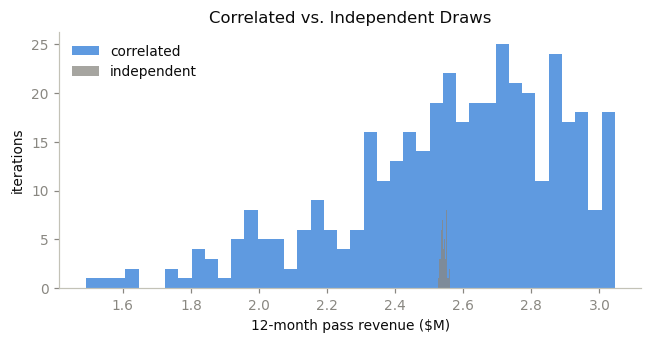

In [6]:
# Test Correlation Structure
def simulate_independent(mult, n_iter=120, rng=None):
    """Wrong on purpose: every trip gets its own economy."""
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        idx = rng.normal(0, 0.35 / np.sqrt(1 - 0.85 ** 2), N)   # independent per trip
        travel_mult = np.exp(0.55 * idx)
        p_occur = np.clip(travel_mult * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base[:, 1].std() / base[:, 1].mean()
ind_sd = indep.std() / indep.mean()

display(pd.DataFrame({
    "median": [np.median(base[:, 1]), np.median(indep)],
    "coefficient of variation": [corr_sd, ind_sd],
    "p5-p95 width": [np.percentile(base[:, 1], 95) - np.percentile(base[:, 1], 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=["correlated (correct)", "independent (wrong)"]).round(4))

print(f"Independent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.")
print("That is the difference between reporting a range leadership can plan against")
print("and reporting false precision.")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base[:, 1] / 1e6, bins=40, alpha=0.75, color=ACCENT, label="correlated")
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label="independent")
ax.set_xlabel("12-month pass revenue ($M)")
ax.set_ylabel("iterations")
ax.set_title("Correlated vs. Independent Draws")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4 · The Price Sweep

**Purpose:** Simulates every price on the grid twice — as fitted, and conservative — so the recommendation accounts for both measured biases.

**Design Notes:**

1. Conservative case stretches the price response by notebook 01 §6.2's ratio and reduction depth by notebook 02 §5's bias
2. The gap between the two curves isn't noise
  - It's the price of two things the analysis couldn't observe directly: whether the response transfers across the book, and whether the reconstructed labels understate real reductions
3. Common random numbers: one seed shared across every price and both cases
  - A different seed per price would let the curve wander by tens of thousands of dollars on sampling noise alone, against a p5-p95 width near $1M

**Observations:**

1. As fitted: median net revenue rises from $2.33M (0.90x) to $2.70M (1.20x)
2. Conservative: median rises from $2.38M to $2.56M — a smaller lift, as expected given both corrections push the same direction
3. Accounts lost climbs from about 26 to about 40 across the range in both cases


As fitted


,p5,median,p95,accounts_lost,lift_vs_base
0.900,1679063,2326493,2652694,26,-152706
0.925,1719078,2379903,2703724,26,-99297
0.950,1712948,2403716,2770081,27,-75484
0.975,1780471,2447783,2791239,28,-31416
1.000,1807364,2479199,2822137,29,0
1.025,1884244,2508862,2878263,30,29663
1.050,1890321,2542637,2913119,30,63438
1.075,1847865,2591954,2961519,32,112755
1.100,1925779,2605308,2989447,33,126109
1.125,1879458,2621962,3026528,34,142763


Conservative


,p5,median,p95,accounts_lost,lift_vs_base
0.900,1749384,2381692,2694313,23,-89477
0.925,1711934,2403459,2763222,24,-67710
0.950,1789892,2415800,2755120,26,-55369
0.975,1794314,2451265,2810908,27,-19904
1.000,1801250,2471169,2812756,29,0
1.025,1917864,2497109,2829671,31,25940
1.050,1787147,2517908,2885459,31,46739
1.075,1904210,2539681,2881613,33,68512
1.100,1873282,2525236,2890306,35,54067
1.125,1842832,2546897,2937967,36,75728


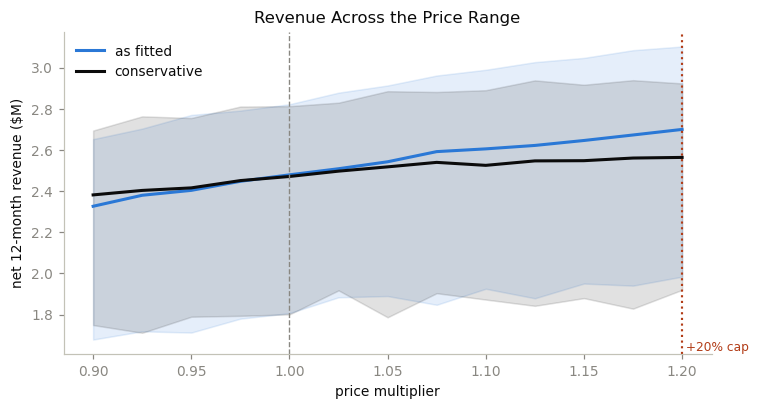

In [7]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [("as fitted", 1.0, 1.0),
                          ("conservative", RESPONSE_RATIO, DEPTH_BIAS)]:
        # Common random numbers: same economy/share/departure draw at every price
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            "price_multiplier": m, "case": label,
            "p5": np.percentile(r[:, 0], 5), "median": np.median(r[:, 0]),
            "p95": np.percentile(r[:, 0], 95),
            "pass_revenue": np.median(r[:, 1]),
            "departure_cost": np.median(r[:, 2]),
            "accounts_lost": np.median(r[:, 3]),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == "as fitted"].set_index("price_multiplier")
cons = sw[sw.case == "conservative"].set_index("price_multiplier")

for df in (fitted, cons):
    df["lift_vs_base"] = df["median"] - df.loc[1.0, "median"]

print("As fitted")
display(fitted[["p5", "median", "p95", "accounts_lost", "lift_vs_base"]].round(0).astype(int).rename_axis(None))
print("Conservative")
display(cons[["p5", "median", "p95", "accounts_lost", "lift_vs_base"]].round(0).astype(int).rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, "as fitted", ACCENT), (cons, "conservative", INK)]:
    ax.plot(df.index, df["median"] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df["p5"] / 1e6, df["p95"] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
ax.axvline(1.20, color="#b23c17", linestyle=":", linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], " +20% cap", fontsize=8, color="#b23c17", va="bottom")
ax.set_xlabel("price multiplier")
ax.set_ylabel("net 12-month revenue ($M)")
ax.set_title("Revenue Across the Price Range")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 5 · Where the Money Comes From, and What It Costs

**Purpose:** Decomposes the net number into pass revenue gained and relationship value lost, since the two sit in different P&Ls and are usually owned by different people.

**Design Notes:**

1. Net comes from the sweep's median NET revenue directly, not from subtracting two separately-medianed components
  - The median of a difference isn't the difference of medians; the shortcut made this table disagree with §4 about which price wins

**Observations:**

1. Best price on net: x1.20
2. Pass revenue gained and relationship value lost both grow with price, but pass revenue grows faster, so net stays positive across the tested range


Conservative case, relative to no price change
(components are medians of their own distributions, so they do not sum
exactly to net — the residual is shown rather than hidden)


,pass_gain,churn_cost,net,unexplained,accounts_lost
0.900,-138404,-30000,-89477,18927,23
0.925,-107127,-28200,-67710,11217,24
0.950,-79024,-19260,-55369,4395,26
0.975,-36588,-10860,-19904,5823,27
1.000,0,0,0,0,29
1.025,18352,3780,25940,11368,31
1.050,56982,6300,46739,-3943,31
1.075,77795,16620,68512,7337,33
1.100,72201,26520,54067,8386,35
1.125,98737,28680,75728,5670,36


Best price on net: x1.200


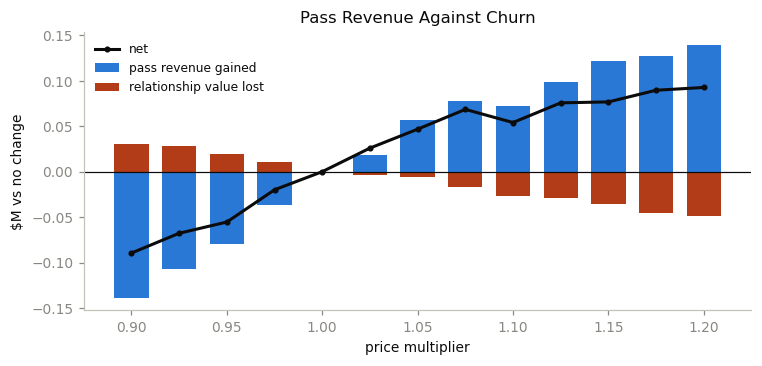

In [8]:
# Decompose Revenue
d = cons[["pass_revenue", "departure_cost", "median", "accounts_lost"]].copy()
d["pass_gain"] = d["pass_revenue"] - cons.loc[1.0, "pass_revenue"]
d["churn_cost"] = d["departure_cost"] - cons.loc[1.0, "departure_cost"]

# Net is the sweep's median NET revenue directly (see Design Notes)
d["net"] = cons["lift_vs_base"]
d["unexplained"] = d["net"] - (d["pass_gain"] - d["churn_cost"])

print("Conservative case, relative to no price change")
print("(components are medians of their own distributions, so they do not sum")
print("exactly to net — the residual is shown rather than hidden)")
display(d[["pass_gain", "churn_cost", "net", "unexplained", "accounts_lost"]].round(0).astype(int).rename_axis(None))
print(f"Best price on net: x{d['net'].idxmax():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(d.index, d["pass_gain"] / 1e6, width=0.018, color=ACCENT, label="pass revenue gained")
ax.bar(d.index, -d["churn_cost"] / 1e6, width=0.018, color="#b23c17",
       label="relationship value lost")
ax.plot(d.index, d["net"] / 1e6, color=INK, linewidth=2, marker="o", ms=3, label="net")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_xlabel("price multiplier")
ax.set_ylabel("$M vs no change")
ax.set_title("Pass Revenue Against Churn")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 6 · Macroeconomic Scenarios

**Purpose:** Tests whether the recommendation holds if the economy turns, since the base case only averages over economic paths.

**Design Notes:**

1. Three scenarios run explicitly: contraction, base, expansion
2. The separation matters for the decision, not just the chart
  - A shortfall from a contracting market is a forecasting miss; a shortfall from customers rejecting the price is a pricing mistake
  - Only the second is reversible by changing the price back, and only the second is anyone's fault

**Observations:**

1. Median net revenue at x1.20 rises in every scenario: $2.19M (contraction), $2.56M (base), $2.81M (expansion)
2. Gain from +20% is close to $0.10M in all three economies
3. The gain holds regardless of the macro forecast — the pricing decision doesn't hinge on which economy materializes


Median net 12-month revenue ($M)


,1.0,1.1,1.2
contraction,2.10,2.16,2.19
base,2.47,2.51,2.56
expansion,2.71,2.79,2.81


Gain from +20% within each economy ($M)


,gain
contraction,0.09
base,0.10
expansion,0.10


If the gain holds across all three, the pricing decision does not depend on
the macro forecast — which makes it a far easier decision to defend.


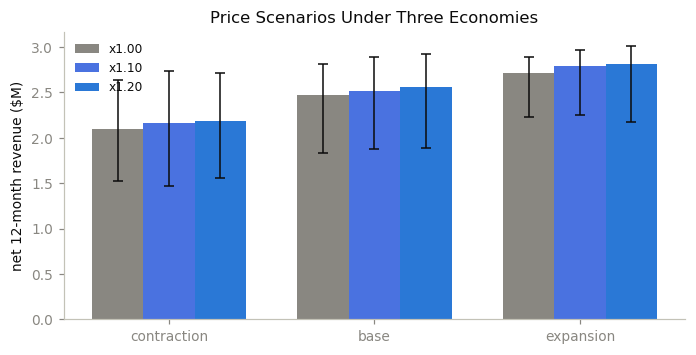

In [9]:
# Test Macro Scenarios
SCEN = {"contraction": -0.45, "base": 0.0, "expansion": +0.45}
KEY = [1.0, 1.10, 1.20]

rows = []
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: only price and macro shift vary
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        rows.append({"scenario": name, "price": m,
                     "p5": np.percentile(r[:, 0], 5), "median": np.median(r[:, 0]),
                     "p95": np.percentile(r[:, 0], 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index="scenario", columns="price", values="median").reindex(SCEN.keys())
print("Median net 12-month revenue ($M)")
display((piv / 1e6).round(2).rename_axis(None).rename_axis(None, axis=1))

print("Gain from +20% within each economy ($M)")
display(((piv[1.20] - piv[1.0]) / 1e6).round(2).to_frame("gain").rename_axis(None))
print("If the gain holds across all three, the pricing decision does not depend on")
print("the macro forecast — which makes it a far easier decision to defend.")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s["median"].to_numpy() / 1e6, width=w,
           color=[MUTED, "#4a72e0", ACCENT][i], label=f"x{m:.2f}")
    ax.errorbar(x, s["median"].to_numpy() / 1e6,
                yerr=[(s["median"] - s["p5"]).to_numpy() / 1e6,
                      (s["p95"] - s["median"]).to_numpy() / 1e6],
                fmt="none", ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel("net 12-month revenue ($M)")
ax.set_title("Price Scenarios Under Three Economies")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 7 · The Recommendation, and Its Honest Caveat

**Purpose:** States the recommendation and its caveat plainly.

**Design Notes:**

1. Read off the conservative case, since both §4/§6.2 biases point the same way, toward overstating safety

**Observations:**

1. Revenue-maximising price: x1.20; median 12-month gain $92,634 (conservative) vs. $220,612 (as fitted)
2. 5th-percentile outcome vs. no change: -$550,802
3. Probability the increase leaves the business worse off: 41.0% — close to a coin flip, presented as a bet with a known downside
4. The optimum sits at the +20% ceiling, not inside the range — the cap chose this price, not the model


In [10]:
# Build Recommendation
best = cons["median"].idxmax()
lift = cons.loc[best, "median"] - cons.loc[1.0, "median"]
lift_fit = fitted.loc[best, "median"] - fitted.loc[1.0, "median"]
downside = cons.loc[best, "p5"] - cons.loc[1.0, "median"]

display(pd.DataFrame({"value": [
    f"x{best:.3f}", f"${lift:,.0f}", f"${lift_fit:,.0f}", f"${downside:,.0f}",
    f"{cons.loc[best, 'accounts_lost']:,.0f}",
]}, index=["revenue-maximising price", "median 12-month gain (conservative)",
           "median 12-month gain (as fitted)", "5th-percentile outcome vs. no change",
           "accounts lost at that price (median)"]))

prob_worse = None
r_best = simulate(best, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
r_base = simulate(1.0, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
prob_worse = float((r_best[:, 0] < r_base[:, 0]).mean())
print(f"Probability the increase leaves us worse off: {prob_worse:.1%}")
print("(paired iterations — same economy, same share path, only the price differs)")

if best < GRID[-1] - 1e-9:
    print("\n" + "=" * 68)
    print(f"The optimum is INTERIOR at x{best:.3f} — revenue turns over before the")
    print("cap. Churn cost outruns pass revenue inside the permitted range, so this")
    print("is a real optimum the model found rather than a constraint it hit. The")
    print("cap is not what limits the recommendation.")
    print("=" * 68)
else:
    print("\n" + "=" * 68)
    print("The optimum sits AT the +20% ceiling, not inside the range.")
    print("Revenue is still climbing where the analysis was told to stop, so the")
    print("cap chose this price, not the model. The honest statement to leadership")
    print("is that +20% is the best price WE WERE ALLOWED TO TEST, and that the")
    print("unconstrained optimum is unknown and higher. Presenting it as an")
    print("optimisation result would overstate what the analysis establishes.")
    print("=" * 68)

if prob_worse > 0.35:
    print(f"\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is")
    print("real but thin against the spread. Present it as a bet with a known")
    print("downside, not as a forecast.")

,value
revenue-maximising price,x1.200
median 12-month gain (conservative),"$92,634"
median 12-month gain (as fitted),"$220,612"
5th-percentile outcome vs. no change,"$-550,802"
accounts lost at that price (median),40


Probability the increase leaves us worse off: 41.0%
(paired iterations — same economy, same share path, only the price differs)

The optimum sits AT the +20% ceiling, not inside the range.
Revenue is still climbing where the analysis was told to stop, so the
cap chose this price, not the model. The honest statement to leadership
is that +20% is the best price WE WERE ALLOWED TO TEST, and that the
unconstrained optimum is unknown and higher. Presenting it as an
optimisation result would overstate what the analysis establishes.

NOTE: at 41%, this is close to a coin flip. The median gain is
real but thin against the spread. Present it as a bet with a known
downside, not as a forecast.


---
## 8 · Export for Power BI

**Purpose:** Writes the price sweep, macro scenarios, and assumptions that notebook 04 loads and the Power BI model displays.

**Design Notes:**

1. Assumptions travel with the export (illustrative ARPU/retention figures alongside measured biases and bootstrap bounds), so nothing is buried in a constant

**Observations:**

1. Three tables written: simulation price sweep, simulation scenarios, simulation assumptions


In [11]:
# Export Results
sim_out = sw.copy()
sim_out["price_change_pct"] = (sim_out["price_multiplier"] - 1) * 100

scen_out = sc.copy()
scen_out["price_change_pct"] = (scen_out["price"] - 1) * 100

assump = pd.DataFrame({
    "assumption": ["ARPU consumer ($/line/mo)", "ARPU business ($/line/mo)",
                   "months counted per lost account", "response scale (conservative)",
                   "depth bias (conservative)", "departure rate low",
                   "departure rate high", "iterations per price",
                   "probability increase is worse"],
    "value": [ARPU_CONSUMER, ARPU_BUSINESS, RETAINED_MONTHS, RESPONSE_RATIO,
              DEPTH_BIAS, DEP_LO, DEP_HI, SWEEP_ITER, prob_worse],
    "note": ["illustrative", "illustrative", "illustrative",
             "measured, notebook 01 §6.2", "measured, notebook 02 §5",
             "bootstrap, notebook 01 §10", "bootstrap, notebook 01 §10",
             "", "paired iterations"],
})
display(assump.set_index("assumption").rename_axis(None))

FMT = "parquet"
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = "csv"
        print("\npyarrow/fastparquet not found, writing CSV instead.")

paths, rows = [], []
for df, name in [(sim_out, "simulation_price_sweep"), (scen_out, "simulation_scenarios"),
                 (assump, "simulation_assumptions")]:
    path = DATA / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    paths.append(path.name)
    rows.append(len(df))

display(pd.DataFrame({"rows": rows}, index=paths).rename_axis(None))

,value,note
ARPU consumer ($/line/mo),65.000000,illustrative
ARPU business ($/line/mo),95.000000,illustrative
months counted per lost account,24.000000,illustrative
response scale (conservative),1.485714,"measured, notebook 01 §6.2"
depth bias (conservative),1.055014,"measured, notebook 02 §5"
departure rate low,0.006801,"bootstrap, notebook 01 §10"
departure rate high,0.008843,"bootstrap, notebook 01 §10"
iterations per price,400.000000,
probability increase is worse,0.410000,paired iterations


,rows
simulation_price_sweep.parquet,26
simulation_scenarios.parquet,9
simulation_assumptions.parquet,9


---
## What this notebook establishes

| Result | Where | Why it matters |
|---|---|---|
| Correlated draws widen the distribution materially | §3.1 | Independent draws would report false precision |
| Two measured biases bracketed, not assumed away | §4 | The recommendation is read off the conservative case |
| Pass revenue and churn cost separated | §5 | The two sit in different P&Ls and are owned by different people |
| The gain holds across economies | §6 | The decision does not hinge on a macro forecast |
| The cap binds | §7 | +20% is a constraint, not an optimum, and must be said that way |

### The one line to carry into the room

Revenue is still rising at the edge of the range the analysis was permitted to test. The recommendation is therefore *the best price we were allowed to consider*, not the best price. Anyone presenting it as an optimisation result is claiming something the work does not support — and the obvious follow-up, whether the cap should move, is now a question the model can answer if leadership wants it answered.

### Next

`04_segmentation.ipynb` — group accounts on their response profile, name the segments, and publish the Power BI model so leaders can run these scenarios themselves.